(P:lab24)=
# Filtering aliasing

Aliasing (french: _crénelage_) is a phenomenon that occurs when the image is poorly sampled.
It can be avoided by applying an anti-aliasing filter (french: _filtre anti-repliement_) before sampling.

:::{warning}
Do not display the images in the notebook in this exercise
because the figure are automatically rescaled and can create aliasing on display.
Instead, save the images with `skimage.io.imsave` and look at them with an external viewer,
by taking care of using a 100% zoom.
:::
  
* Load and display the image {download}`roof.jpg`.
  Then, downsample it (without an anti-aliasing filter) by a factor of three by taking one pixel out of three in the two spatial dimensions,
  which can be done with the instruction
  :::python
  f[::3,::3]
  :::
  How does the phenomenon of aliasing appear visually?
  
* Now, apply a Gaussian filter (`skimage.filters.gaussian`) to the original image before downsampling.
  Adjust the filter parameter to minimize aliasing.
  Is the aliasing still visible?
  
* Lastly, replace the Gaussian filter with an ideal low-pass filter,
  which completely eliminates frequencies above the cutoff frequency without modifying the frequencies below.
  The process is:
  1. Compute the DFT of the image,
  2. Define the ideal filter as a zero image with a square of 1 in the Fourier domain,
  3. Multiply the DFT of the image with the filter (this is equivalent to a convolution in the spatial domain),
  4. Compute the inverse DFT of the result (and keep only the real part).
  
  The code below generates a binary square mask of the same size as the image `X`:
  :::python
  Mask = np.zeros(X.shape)
  Mask[a:b,c:d] = 1
  :::
  Choose correctly the coordinates `a`, `b`, `c` and `d` to conserve the low frequencies,
  which are located at the center in the DFT (after applying `numpy.fft.fftshift`).
  
  The ideal filter may be defined in the same way as in the exercise [](lab14):
  use the function `numpy.zeros` and the indexing `f[m1:m2,n1:n2] = x`.
  Choose the cutoff frequency appropriately to reduce aliasing without altering the image.
  Is the aliasing still visible?
  

  
<!--
## Magnitude and phase of the Fourier transform

* Load the image [lena.tiff](https://vincmazet.github.io/ftip/_static/data/lena.tiff) and convert it to grayscale.

* Compute its DFT.

* Reconstruct the image by using the inverse DFT, but using a constant magnitude.
  To do that, you have to define the DFT from the magnitude and the argument, considering that
  
  $$
    X = \rho \exp(j\theta)
  $$
  
  where $X$ is the DFT, $\rho$ the magnitude and $\theta$ the phase.
  In Python, the exponential is `numpy.exp` and the multiplication is simply `*`.
  To define a constant magnitude with the same size as the DFT,
  you can use the code:
  
  ```
  numpy.ones(F.shape)
  ```
  
  It is possible that the image is complex, because of numerical errors.
  To avoid this, display the real part (`numpy.real`) of the image.

* Same question, but using the initial magnitude but a constant argument.

* What do you conclude?
-->
  
<!-- 
## convolution et problèmes aux bords

problème aux bords : je donne une image super grande et un filtre.
Je leur demande d'appliquer le filtre sur l'image et de ne sélectionner/afficher qu'une zone (de 100x100).
L'application du filtre sur toute l'image n'est pas possible (image trop grande).
Solution : sélectionner une partie de l'image et y appliquer le filtre.
Mais à cause du bord, il faut sélectionner une image un peu plus grande que ce qui est demandé.
-->

<!--
## convolution et séparabilité
-->

<!--
 ## retrouver le fond dans une vidéo

une séquence de 10 images dans laquelle quelques objets se déplacent
comment retrouver le fond (c'est à dire sans les objets) ?

Idée 1 : division entre images deux à deux pour déterminer quels sont les pixels qui ne changent pas, et les enregistrer comme étant le fond

Idée 2 : filtre médian en chaque pixel
-->

* * *

## Correction

**📌 Commentaires pour les intervenants

* Attention, comme il est question de crénelage (_aliasing_), il ne faut pas afficher les images dans le notebook avec `imshow`,
  car les images seront forcément affichées avec un zoom qu'on ne peut pas contrôler, et donc qui risque d'ajouter de l'aliasing...
  À la place, utiliser l'afficheur Linux de base après avoir enregistré les images, en veillant à avoir un zoom à 100 %.
  On peut d'ailleurs faire en sorte que cet afficheur soit toujours visible
  en cliquant sur la barre de titre de la fenêtre avec le bouton droit,
  puis en sélectionnant « Toujours au premier plan ».
  Tout ceci sera à faire en point oral aux étudiants.
  
* Un autre point oral à faire : expliquer comment fonctionne le masque à appliquer sur la TFD de l'image.
  Je pense qu'un petit schéma de ce masque, en expliquant les coordonnées du carré de 1 peut être intéressant.
  
* Pour éviter les problèmes de conversion lors de l'enregistrement des images, utiliser : `skimage.img_as_ubyte` et `.astype(np.uint8)`.

In [1]:
import numpy as np
import skimage.io as io
import skimage.filters as flt
import matplotlib.pyplot as plt
from skimage import img_as_ubyte

### Objectives

* Define and apply a filter for a real application.
* Discover aliasing in images.

### Downsampling and filtering

Three images are generated:
* the original one, rescaled by a factor $S$,
* the original one, filtered by a Gaussian filter, then rescaled by a factor $S$,
* the original one, filtered by an ideal low-pass filter (defined in the Fourier domain), then rescaled by a factor $S$.

Note that when using the inverse Fourier transform, you may have to get the real part of the result, if it is complex.

In [2]:
# Original image
x = io.imread("roof.jpg")

In [3]:
# Scaling without low-pass filtering
y = x[::3,::3]
io.imsave("roof-none.png",y)

In [4]:
# Scaling with Gaussian filtering
x_filtered = flt.gaussian(x, 1.4)
y = x_filtered[::3,::3]
io.imsave("roof-gaussian.png",img_as_ubyte(y))

In [5]:
# Scaling with ideal low-pass filtering, in the Fourier domain

# Image FFT
X = np.fft.fft2(x)
X = np.fft.fftshift(X)

The mask is of the same size that the Fourier transform `X` of the original image.
The low frequencies must be 1 and the high frequency 0, as in the image below (the pixels 1 are in the center to manage the use of `fftshift`):

In [6]:
# Zero image
M, N = X.shape
Mask = np.zeros((M,N))

# Cutoff frequency (between 0 and 1)
f = .33

# Region where the filter equals 1
a = int(M/2*(1-f))
b = int(M/2*(1+f))
c = int(N/2*(1-f))
d = int(N/2*(1+f))
Mask[a:b,c:d] = 1

In [7]:
X_filtered = X*Mask
X_masked = X_filtered.copy() # for display

# Inverse FFT
X_filtered = np.fft.ifftshift(X_filtered)
x_filtered = np.fft.ifft2(X_filtered)
x_filtered = np.real(x_filtered)
y = x_filtered[::3,::3]

io.imsave("roof-ideal.png",y.astype(np.uint8))

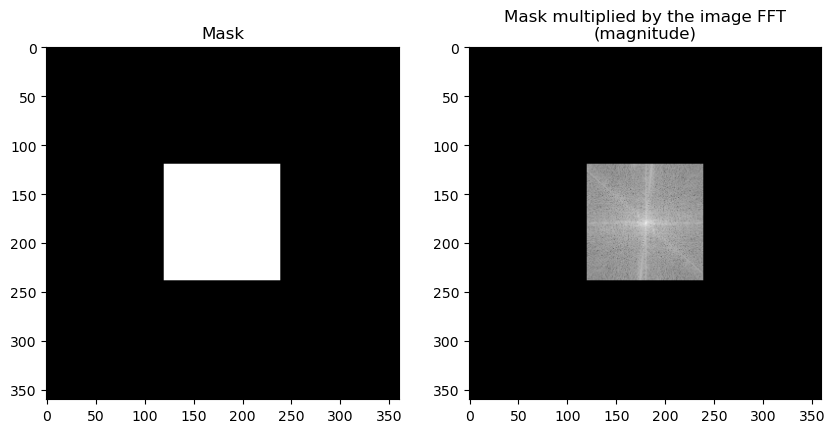

In [8]:
# Display the mask

fig, axs = plt.subplots(1, 2, figsize=(10,5))
axs[0].imshow(Mask, cmap="gray")
axs[0].set_title("Mask")
axs[1].imshow(np.log(np.abs(X_masked)+1e-1), cmap="gray")
axs[1].set_title("Mask multiplied by the image FFT\n(magnitude)")
plt.show()

Note that the cutoff frequency equals $1/S$ to avod aliasing.

You should obtain the following results.
The aliasing is clearly visible on the first image, where no filter has been applied:
a weird effect is visible on the tiles.
The Gaussian filter strongly attenuates the effect, and the ideal filter is better.

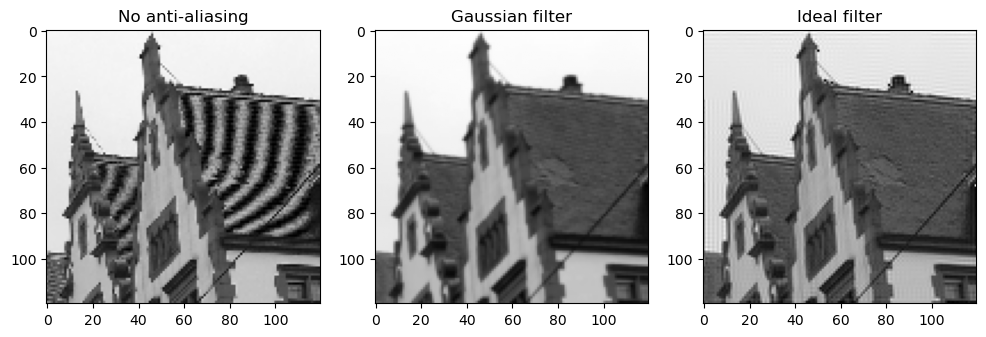

In [9]:
images = ["roof-none", "roof-gaussian", "roof-ideal"]
titles = ["No anti-aliasing", "Gaussian filter", "Ideal filter"]
fig, axs = plt.subplots(1, 3, figsize=(12,5))
for i in range(len(images)):
    x = io.imread(f"{images[i]}.png")
    axs[i].imshow(x, cmap="gray")
    axs[i].set_title(titles[i])
plt.show()